<a href="https://colab.research.google.com/github/Erjg1012/predicciones/blob/main/predicci%C3%B3n_de_contaminaci%C3%B3n_con_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Análisis de contaminantes en Bengaluru India

## 1. Importación de Librerías

Se importan las librerías necesarias para manipular datos, ajustar modelos estadísticos de series de tiempo, visualizar resultados y calcular métricas de error. pandas y numpy se usan para manejar los datos; matplotlib y seaborn para graficar; ARIMA y SARIMAX para modelar; y mean_squared_error para evaluar la precisión de las predicciones.

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error


sns.set_style("whitegrid")  # Activa el estilo whitegrid desde Seaborn


## 2. Carga y Preprocesamiento de Datos

Se carga el archivo city_day.csv y se convierte la columna Date en formato de fecha. Luego, se filtran los registros correspondientes únicamente a la ciudad de Bengaluru, y se eliminan los valores nulos en la columna AQI. Esto prepara los datos para el análisis.

In [ ]:
# Cargar y preparar datos
df = pd.read_csv("city_day.csv")
df["Date"] = pd.to_datetime(df["Date"])
bengaluru_df = df[df["City"] == "Bengaluru"].copy()
bengaluru_df = bengaluru_df.set_index("Date").sort_index()
bengaluru_df = bengaluru_df[["AQI"]].dropna()


## 3. Prueba de Estacionariedad (ADF)

Se aplica la prueba Augmented Dickey-Fuller (ADF) para verificar si la serie temporal del AQI es estacionaria. Esta prueba es crucial, ya que los modelos ARIMA y SARIMAX requieren series estacionarias para un ajuste adecuado. Un p-valor menor a 0.05 indicaría que la serie ya es estacionaria.

In [ ]:
# Prueba ADF
result = adfuller(bengaluru_df["AQI"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -6.077777770177216
p-value: 1.1108572405973835e-07


## 4. Análisis de ACF y PACF

Se generan las gráficas de autocorrelación (ACF) y autocorrelación parcial (PACF). Estas gráficas ayudan a determinar los valores adecuados para los parámetros p y q del modelo ARIMA. También se puede observar si hay estacionalidad evidente.

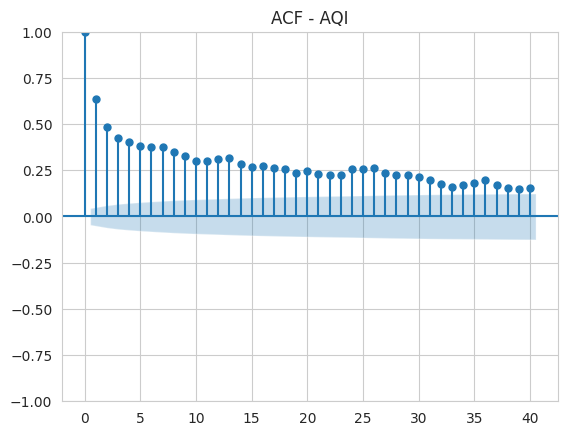

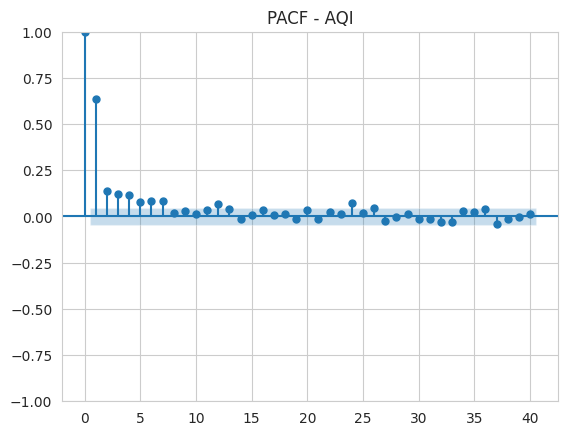

In [ ]:
# ACF y PACF
plot_acf(bengaluru_df["AQI"], lags=40)
plt.title("ACF - AQI")
plt.show()

plot_pacf(bengaluru_df["AQI"], lags=40)
plt.title("PACF - AQI")
plt.show()


## 5. División de Datos (5 años)

Se divide la serie completa (2015–2020) en dos conjuntos: uno de entrenamiento con las primeras 1600 observaciones, y otro de prueba con el resto. Esta división permite entrenar el modelo y luego evaluar su rendimiento con datos no vistos.

In [ ]:
# Dividir datos en entrenamiento y prueba (5 años)
train = bengaluru_df["AQI"][:1600]
test = bengaluru_df["AQI"][1600:]


## 6. Ajuste del Modelo ARIMA

Se ajusta un modelo ARIMA(2,1,2) sobre los datos de entrenamiento. Este modelo considera dos rezagos autorregresivos, una diferenciación para hacer la serie estacionaria, y dos rezagos de la media móvil. Se calcula el RMSE entre las predicciones y los datos reales de prueba.

In [ ]:
#  Modelo ARIMA(2,1,2) con 5 años
model_arima = ARIMA(train, order=(2, 1, 2)).fit()
forecast_arima = model_arima.forecast(steps=len(test))
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
print(f"RMSE ARIMA (5 años): {rmse_arima:.2f}")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

RMSE ARIMA (5 años): 27.02


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## 7. Ajuste del Modelo SARIMAX

Se ajusta un modelo SARIMAX(2,1,2)(1,1,1,12) sobre el mismo conjunto. Este modelo añade una componente estacional con periodicidad mensual. También se calcula el RMSE para evaluar su precisión frente al ARIMA.

In [ ]:
#  Modelo SARIMAX(2,1,2)(1,1,1,12) con 5 años
model_sarimax = SARIMAX(train, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)).fit()
forecast_sarimax = model_sarimax.forecast(steps=len(test))
rmse_sarimax = np.sqrt(mean_squared_error(test, forecast_sarimax))
print(f"RMSE SARIMAX (5 años): {rmse_sarimax:.2f}")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


RMSE SARIMAX (5 años): 31.66


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## 8. Visualización Comparativa (5 años)

Se grafican las predicciones del ARIMA y del SARIMAX junto con los valores reales del AQI para los últimos 300 días. Esta gráfica permite comparar visualmente cuál modelo sigue mejor la evolución real del AQI.

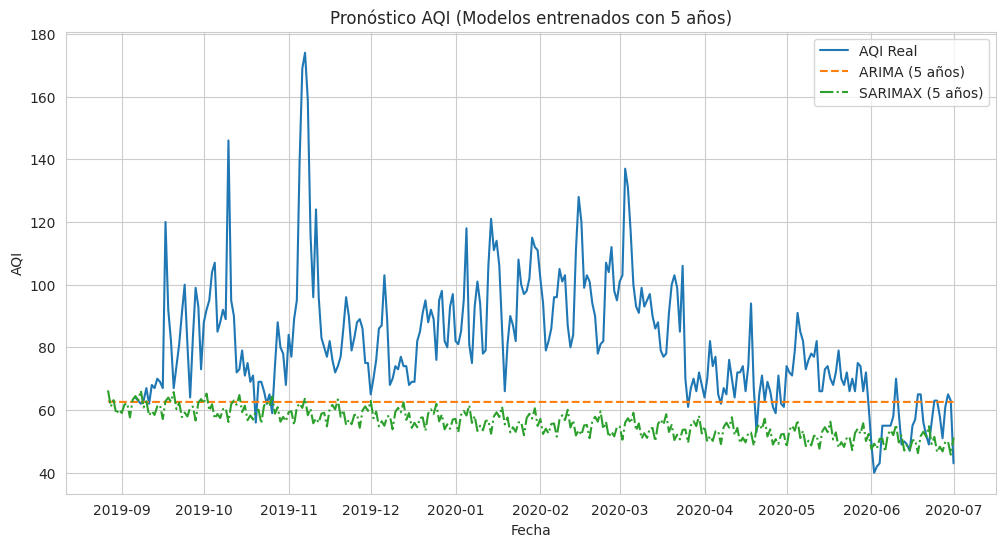

In [ ]:
#  Visualización modelos 5 años
plt.figure(figsize=(12, 6))
plt.plot(bengaluru_df.index[-300:], bengaluru_df["AQI"][-300:], label="AQI Real")
plt.plot(test.index, forecast_arima, label="ARIMA (5 años)", linestyle='--')
plt.plot(test.index, forecast_sarimax, label="SARIMAX (5 años)", linestyle='-.')
plt.title("Pronóstico AQI (Modelos entrenados con 5 años)")
plt.xlabel("Fecha")
plt.ylabel("AQI")
plt.legend()
plt.show()


## 9. Pronóstico de los Próximos 30 Días

Utilizando el modelo SARIMAX ajustado con los 5 años, se genera un pronóstico para los siguientes 30 días. Esto sirve como una aplicación práctica para prever la calidad del aire y tomar decisiones preventivas.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


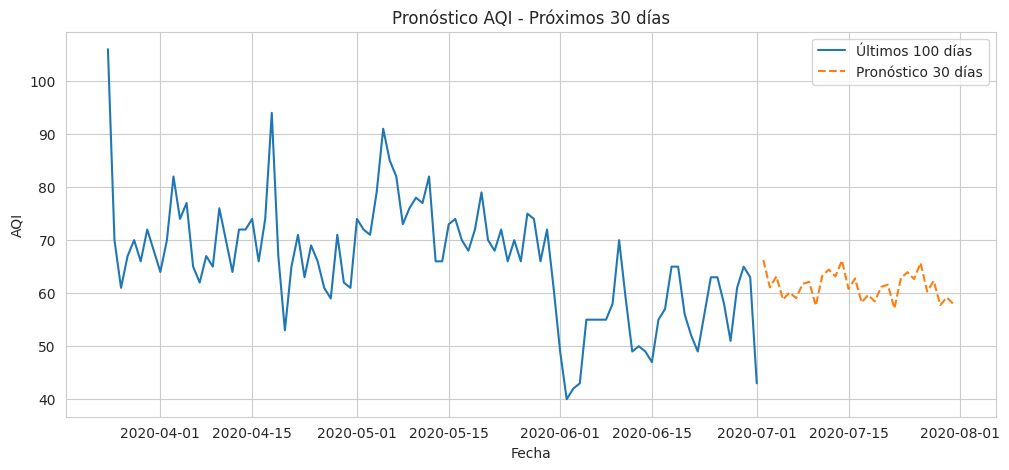

In [ ]:
#  Pronóstico futuro 30 días (SARIMAX 5 años)
forecast_30 = model_sarimax.forecast(steps=30)
plt.figure(figsize=(12, 5))
plt.plot(bengaluru_df["AQI"][-100:], label="Últimos 100 días")
plt.plot(pd.date_range(bengaluru_df.index[-1], periods=31, freq='D')[1:], forecast_30,
         label="Pronóstico 30 días", linestyle="--")
plt.title("Pronóstico AQI - Próximos 30 días")
plt.xlabel("Fecha")
plt.ylabel("AQI")
plt.legend()
plt.show()


## 10. Entrenamiento con Solo 3 Años (2018–2020)

Se repite el proceso anterior, pero esta vez considerando únicamente los datos más recientes (2018–2020). Se entrena un modelo ARIMA y uno SARIMAX sobre estos datos para evaluar si usar menos años mejora la precisión al enfocarse en patrones actuales.

In [ ]:
#  Entrenamiento con datos recientes: 2018–2020 (3 años)
recent_3yrs_df = bengaluru_df[bengaluru_df.index.year.isin([2018, 2019, 2020])]
recent_3yrs_df = recent_3yrs_df[["AQI"]].dropna()

train_3yrs = recent_3yrs_df["AQI"][:int(len(recent_3yrs_df)*0.8)]
test_3yrs = recent_3yrs_df["AQI"][int(len(recent_3yrs_df)*0.8):]


## 11. Evaluación de Modelos (3 años)

Se calculan las predicciones y el RMSE para los modelos ARIMA y SARIMAX entrenados con 3 años. Estos valores se comparan con los obtenidos anteriormente usando los 5 años.

In [ ]:
#  Modelo ARIMA (3 años)
model_arima_3yrs = ARIMA(train_3yrs, order=(2, 1, 2)).fit()
forecast_arima_3yrs = model_arima_3yrs.forecast(steps=len(test_3yrs))
rmse_arima_3yrs = np.sqrt(mean_squared_error(test_3yrs, forecast_arima_3yrs))


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [ ]:
#  Modelo SARIMAX (3 años)
model_sarimax_3yrs = SARIMAX(train_3yrs, order=(2, 1, 2), seasonal_order=(1, 1, 1, 12)).fit()
forecast_sarimax_3yrs = model_sarimax_3yrs.forecast(steps=len(test_3yrs))
rmse_sarimax_3yrs = np.sqrt(mean_squared_error(test_3yrs, forecast_sarimax_3yrs))


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python

## 12. Tabla Comparativa Final

Se presenta una tabla que resume los modelos, sus respectivos RMSE, el periodo de entrenamiento y si consideran estacionalidad. Esta tabla permite evaluar de forma clara qué combinación ofrece el mejor rendimiento.

In [ ]:
#  Comparación final de modelos
comparacion_df = pd.DataFrame({
    "Modelo": ["ARIMA (5 años)", "SARIMAX (5 años)", "ARIMA (3 años)", "SARIMAX (3 años)"],
    "RMSE": [rmse_arima, rmse_sarimax, rmse_arima_3yrs, rmse_sarimax_3yrs],
    "Entrenamiento": ["2015–2020", "2015–2020", "2018–2020", "2018–2020"],
    "Estacionalidad": ["No", "Sí", "No", "Sí"]
})
print(comparacion_df)


             Modelo       RMSE Entrenamiento Estacionalidad
0    ARIMA (5 años)  27.024331     2015–2020             No
1  SARIMAX (5 años)  31.663489     2015–2020             Sí
2    ARIMA (3 años)  20.129025     2018–2020             No
3  SARIMAX (3 años)  19.601674     2018–2020             Sí


## 13. Visualización Comparativa (3 años)

Se grafican las predicciones de ARIMA y SARIMAX para el periodo 2018–2020. Esto permite verificar visualmente si los modelos más recientes capturan mejor los cambios en el AQI, especialmente después del impacto del COVID y políticas ambientales recientes.

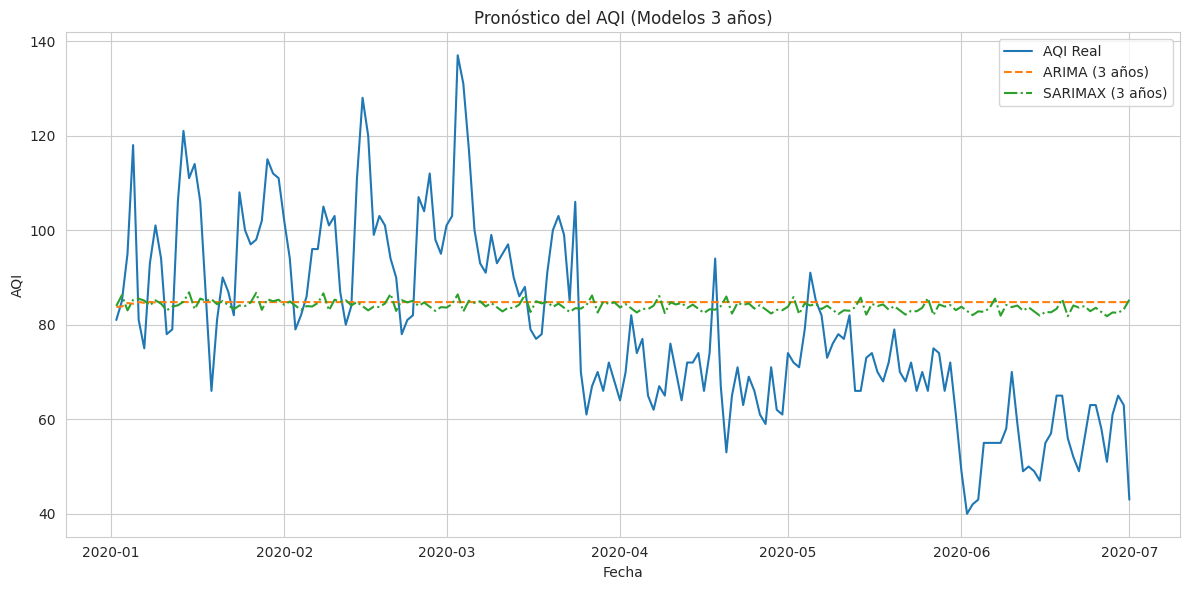

In [ ]:
#  Gráfica comparación de modelos 3 años
plt.figure(figsize=(12, 6))
plt.plot(test_3yrs.index, test_3yrs, label="AQI Real")
plt.plot(test_3yrs.index, forecast_arima_3yrs, label="ARIMA (3 años)", linestyle='--')
plt.plot(test_3yrs.index, forecast_sarimax_3yrs, label="SARIMAX (3 años)", linestyle='-.')
plt.title("Pronóstico del AQI (Modelos 3 años)")
plt.xlabel("Fecha")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()


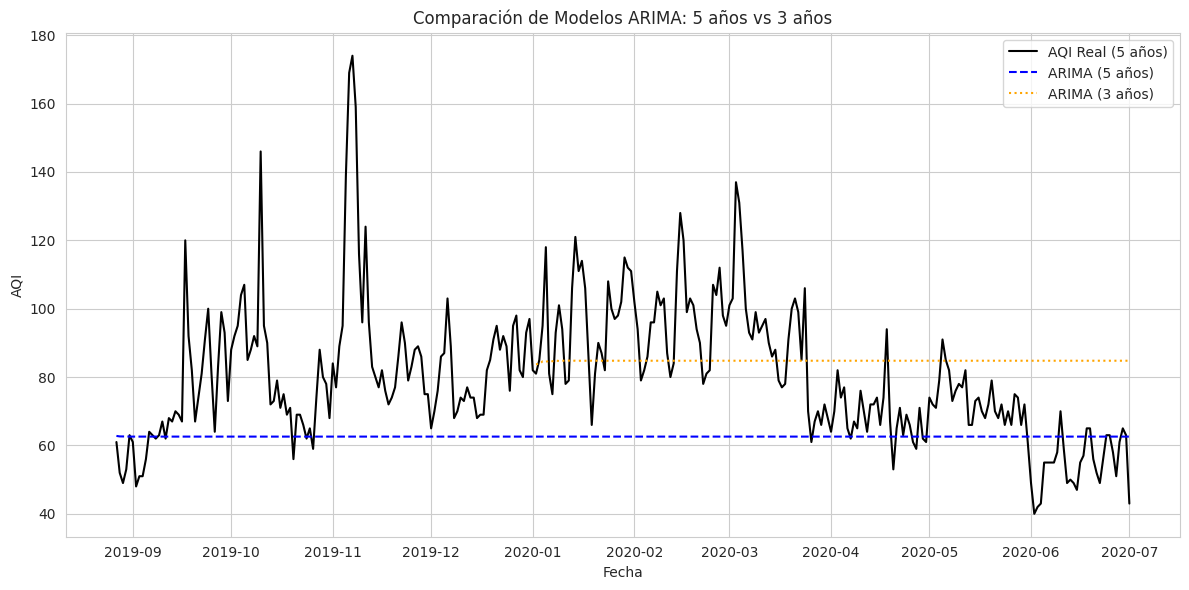

In [ ]:
# 📈 Comparación visual ARIMA 5 años vs ARIMA 3 años
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label="AQI Real (5 años)", color='black')
plt.plot(test.index, forecast_arima, label="ARIMA (5 años)", linestyle='--', color='blue')
plt.plot(test_3yrs.index, forecast_arima_3yrs, label="ARIMA (3 años)", linestyle=':', color='orange')
plt.title("Comparación de Modelos ARIMA: 5 años vs 3 años")
plt.xlabel("Fecha")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


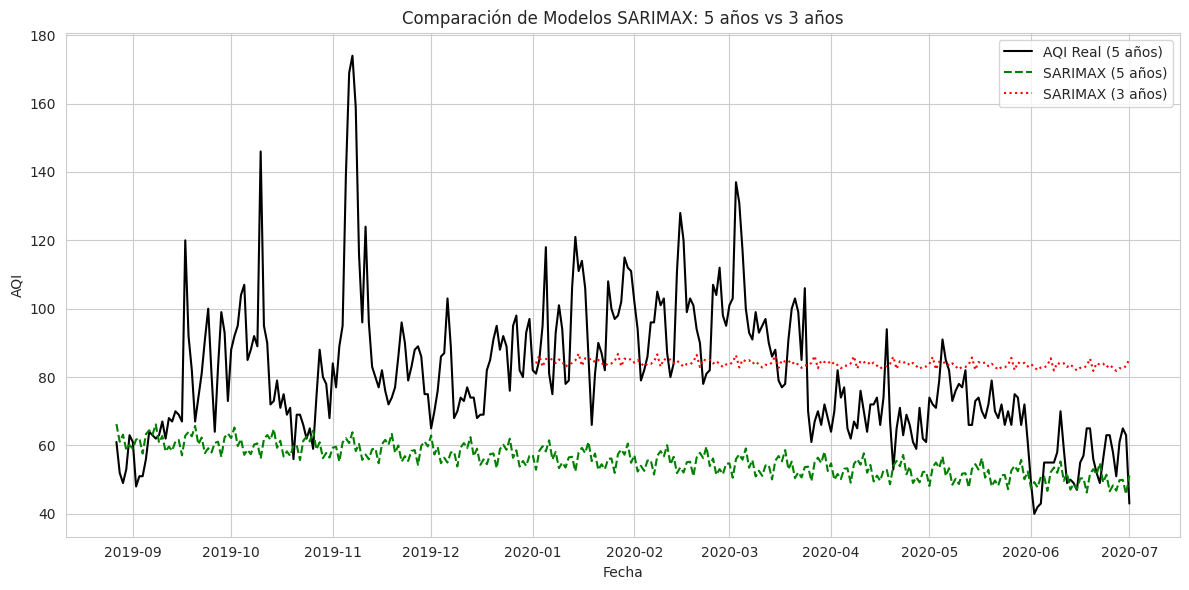

In [ ]:
# 📉 Comparación visual SARIMAX 5 años vs SARIMAX 3 años
plt.figure(figsize=(12, 6))
plt.plot(test.index, test, label="AQI Real (5 años)", color='black')
plt.plot(test.index, forecast_sarimax, label="SARIMAX (5 años)", linestyle='--', color='green')
plt.plot(test_3yrs.index, forecast_sarimax_3yrs, label="SARIMAX (3 años)", linestyle=':', color='red')
plt.title("Comparación de Modelos SARIMAX: 5 años vs 3 años")
plt.xlabel("Fecha")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# 📋 Tabla comparativa de desempeño con Δ RMSE respecto al modelo SARIMAX (5 años)
comparacion_df = pd.DataFrame({
    "Modelo": ["ARIMA (5 años)", "SARIMAX (5 años)", "ARIMA (3 años)", "SARIMAX (3 años)"],
    "RMSE": [rmse_arima, rmse_sarimax, rmse_arima_3yrs, rmse_sarimax_3yrs],
    "Entrenamiento": ["2015–2020", "2015–2020", "2018–2020", "2018–2020"],
    "Estacionalidad": ["No", "Sí", "No", "Sí"]
})
comparacion_df["Δ RMSE vs SARIMAX (5 años)"] = comparacion_df["RMSE"].apply(
    lambda x: f"{((x - rmse_sarimax) / rmse_sarimax * 100):.2f}%"
)

# Mostrar tabla
print(comparacion_df)


             Modelo       RMSE Entrenamiento Estacionalidad  \
0    ARIMA (5 años)  27.024331     2015–2020             No   
1  SARIMAX (5 años)  31.663489     2015–2020             Sí   
2    ARIMA (3 años)  20.129025     2018–2020             No   
3  SARIMAX (3 años)  19.601674     2018–2020             Sí   

  Δ RMSE vs SARIMAX (5 años)  
0                    -14.65%  
1                      0.00%  
2                    -36.43%  
3                    -38.09%  



### SARIMA (sin variable exógena)


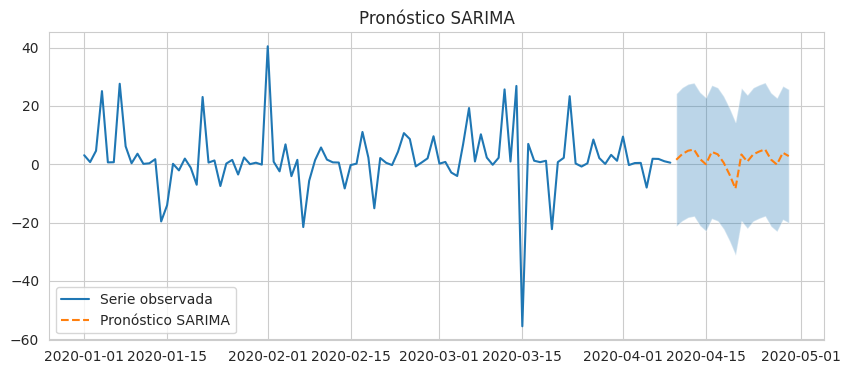

In [ ]:
# ========================================
# 4. Modelo SARIMA (sin exógenas)
# ========================================
print("\n### SARIMA (sin variable exógena)")
modelo_sarima = SARIMAX(serie_temporal, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit()
forecast_sarima = modelo_sarima.get_forecast(steps=20)
conf_int_sarima = forecast_sarima.conf_int()
lower = conf_int_sarima.iloc[:, 0].astype(float)
upper = conf_int_sarima.iloc[:, 1].astype(float)

# Visualización SARIMA
plt.figure(figsize=(10, 4))
plt.plot(serie_temporal, label="Serie observada")
plt.plot(forecast_sarima.predicted_mean.index, forecast_sarima.predicted_mean, label="Pronóstico SARIMA", linestyle="--")
plt.fill_between(forecast_sarima.predicted_mean.index, lower, upper, alpha=0.3)
plt.title("Pronóstico SARIMA")
plt.legend()
plt.grid(True)
plt.show()



### SARIMAX (con variable exógena X1)


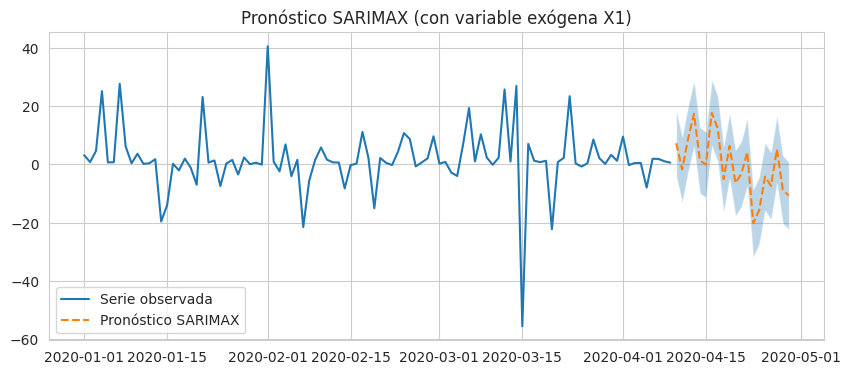

In [ ]:
# ========================================
# 5. Modelo SARIMAX (con X1 como exógena)
# ========================================
print("\n### SARIMAX (con variable exógena X1)")
X_df = pd.DataFrame({f"X{i}": X**i for i in range(1, 4)})
X_exog = pd.Series(X_df["X1"].values, index=fecha_inicio)

modelo_sarimax = SARIMAX(serie_temporal, exog=X_exog, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12)).fit()
forecast_sarimax = modelo_sarimax.get_forecast(steps=20, exog=X_exog[:20])
conf_int_sarimax = forecast_sarimax.conf_int()
lower_smx = conf_int_sarimax.iloc[:, 0].astype(float)
upper_smx = conf_int_sarimax.iloc[:, 1].astype(float)

# Visualización SARIMAX
plt.figure(figsize=(10, 4))
plt.plot(serie_temporal, label="Serie observada")
plt.plot(forecast_sarimax.predicted_mean.index, forecast_sarimax.predicted_mean, label="Pronóstico SARIMAX", linestyle="--")
plt.fill_between(forecast_sarimax.predicted_mean.index, lower_smx, upper_smx, alpha=0.3)
plt.title("Pronóstico SARIMAX (con variable exógena X1)")
plt.legend()
plt.grid(True)
plt.show()